## Submission analysis notebook
* Fix train and valid transforms later.

### Imports

In [35]:
import os
import gc
import math

# Cell Segmentator Tool
import hpacellseg.cellsegmentator as cellsegmentator
from hpacellseg.utils import label_cell

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

import torch
import torchvision
from torchvision.io import read_image

from models import HPAClassifier
from dataset import HPADatasetFourChannelsImages
from utils import train_valid_split_multilabel, train_transformations, valid_transformations

### Train and valid transforms

In [ ]:
def train_transformations(image_normalization: str) -> transforms.Compose:
    '''
    Returns a composition of transformations to be applied to the training images.
    Returns:
        transforms.Compose
            The composition of transformations.
    '''
    if image_normalization == "imagenet":
        return transforms.Compose([
            transforms.ToImage(), # Transformar de tensor para imagem
            # transforms.Resize((512, 512)),
            transforms.Resize((512, 512), interpolation=transforms.InterpolationMode.LANCZOS),
            transforms.ToDtype(torch.float32, scale=True),
            transforms.Normalize(mean=[0.485, 0.456, 0.406, 0.485], std=[0.229, 0.224, 0.225, 0.229])
        ])
    elif image_normalization == "basic-0.5":
        return transforms.Compose([
            transforms.ToImage(), # Transformar de tensor para imagem
            transforms.Resize((512, 512)),
            transforms.ToDtype(torch.float32, scale=True),
            transforms.Normalize(mean=[0.5, 0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5, 0.5])
        ])
    elif image_normalization == "divide-255":
        return transforms.Compose([
            transforms.ToImage(), # Transformar de tensor para imagem
            transforms.Resize((512, 512)),
            transforms.ToDtype(torch.float32, scale=True)
        ])
    else:
        raise ValueError(f"Unknown image normalizer: {image_normalization}")


def valid_transformations(image_normalization: str) -> transforms.Compose:
    '''
    Returns a composition of transformations to be applied to the validation images.
    Returns:
        transforms.Compose
            The composition of transformations.
    '''
    if image_normalization == "imagenet":
        return transforms.Compose([
            transforms.Lambda(lambda img: to_pil_image(img) if isinstance(img, torch.Tensor) else img),  # Converte para PIL
            transforms.Resize((512, 512), interpolation=InterpolationMode.LANCZOS),  # Resize com Lanczos
            transforms.ToTensor(),  # Converte de volta para tensor
            transforms.ToDtype(torch.float32, scale=True),  # Converte dtype
            transforms.Normalize(mean=[0.485, 0.456, 0.406, 0.485], std=[0.229, 0.224, 0.225, 0.229])  # Normalização
        ])
    elif image_normalization == "basic-0.5":
        return transforms.Compose([
            transforms.ToImage(), # Transformar de tensor para imagem
            transforms.Resize((512, 512)),
            transforms.ToDtype(torch.float32, scale=True),
            transforms.Normalize(mean=[0.5, 0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5, 0.5])
        ])
    elif image_normalization == "divide-255":
        return transforms.Compose([
            transforms.ToImage(), # Transformar de tensor para imagem
            transforms.Resize((512, 512)),
            transforms.ToDtype(torch.float32, scale=True)
        ])
    else:
        raise ValueError(f"Unknown image normalizer: {image_normalization}")

### Read Image [Functions]

In [80]:
def read_image_chw(filename):
    """
    Read an image and convert it to a tensor with shape (C, H, W)

    Args:
        filename (str): the filename of the image

    Returns:
        torch.Tensor: the image as a tensor

    """

    colors = ["_blue", "_red", "_yellow", "_green"]
    images = [read_image(os.path.join(ROOT + "train/" + filename + color + ".png")) for color in colors]
    image = torch.cat(images, 0)

    return image

In [81]:
# read sample image
# check the image dtype, ensure it is in uint8
def read_sample_image(filename):
    
    '''
    read individual images
    of different filters (R, G, B, Y)
    and stack them.
    ---------------------------------
    Arguments:
    filename -- sample image path
    
    Returns:
    stacked_images -- stacked (RGBY) image
    '''
    
    blue = cv2.imread(os.path.join(ROOT, 'train/') + filename + "_blue.png", cv2.IMREAD_UNCHANGED)
    red = cv2.imread(os.path.join(ROOT, 'train/') + filename + "_red.png", cv2.IMREAD_UNCHANGED)
    yellow = cv2.imread(os.path.join(ROOT, 'train/') + filename + "_yellow.png", cv2.IMREAD_UNCHANGED)
    green = cv2.imread(os.path.join(ROOT, 'train/') + filename + "_green.png", cv2.IMREAD_UNCHANGED)

    stacked_images = np.transpose(np.array([blue, red, yellow, green]), (1,2,0))
    return stacked_images

In [82]:
# read sample image to segment
# check the image dtype, ensure it is in uint8
def read_sample_image_seg(filename):
    
    '''
    read individual images
    of different filters (R, B, Y)
    and stack them for segmentation.
    ---------------------------------
    Arguments:
    filename -- sample image file path
    
    Returns:
    stacked_images -- stacked (RBY) image path in lists.
    '''
    
    red = os.path.join(ROOT, 'train/') + filename + "_red.png"
    blue = os.path.join(ROOT, 'train/') + filename + "_blue.png"
    yellow = os.path.join(ROOT, 'train/') + filename + "_yellow.png"

    stacked_images = [[red], [yellow], [blue]]
    return stacked_images, red, blue, yellow

### Segment Cells [Function]

In [7]:
# segment cell 
def segmentCell(image, segmentator):
    
    '''
    segment cell and nuclei from
    microtubules, endoplasmic reticulum,
    and nuclei (R, B, Y) filters.
    ------------------------------------
    Argument:
    image -- (R, B, Y) list of image arrays
    segmentator -- CellSegmentator class object
    
    Returns:
    cell_mask -- segmented cell mask
    '''
    
    nuc_segmentations = segmentator.pred_nuclei(image[2])
    cell_segmentations = segmentator.pred_cells(image)
    nuclei_mask, cell_mask = label_cell(nuc_segmentations[0], cell_segmentations[0])
    
    gc.collect(); del nuc_segmentations; del cell_segmentations; del nuclei_mask
    
    return cell_mask

### Plot Images [Functions]

In [8]:
# Define colors for each channel (Red, Green, Blue, Orange)
channel_colors = {
    'blue': (0, 0, 1, 0.7),     # Blue with transparency
    'red': (1, 0, 0, 0.7),      # Red with transparency
    'orange': (1, 0.6, 0, 0.7),  # Orange with transparency
    'green': (0, 1, 0, 0)       # Green with transparency
}

In [9]:
def apply_channel_colors(image):
    """
    Applies color mapping to a 4-channel image.

    Args:
        image (np.ndarray): The 4-channel input image.

    Returns:
        np.ndarray: RGB image with blended channels.
    """
    # Initialize an empty RGB image
    combined_image = np.zeros(image.shape[:2] + (3,), dtype=np.float32)

    # Overlay each channel with corresponding color
    for j, (_, color) in enumerate(channel_colors.items()):
        channel = image[:, :, j].astype(np.float32)

        # Normalize channel to [0,1]
        channel = (channel - np.min(channel)) / (np.max(channel) - np.min(channel) + 1e-5)

        # Apply color mapping
        for k in range(3):
            combined_image[:, :, k] += channel * color[k]

    # Clip values to [0,1] for valid image display
    combined_image = np.clip(combined_image, 0, 1)

    return combined_image

In [88]:
def plot_image(image):
    """
    Plots an image with color overlays for each channel.

    Args:
        image (np.ndarray): Image with shape (C, H, W), where C = 4 (multi-channel).
    """
    if image.shape[0] != 4:
        raise ValueError("Expected image with 4 channels (C, H, W).")

    # Convert (C, H, W) -> (H, W, C) for visualization
    image = np.transpose(image, (1, 2, 0))

    # Initialize empty RGB image
    combined_image = np.zeros((image.shape[0], image.shape[1], 3), dtype=np.float32)

    # Overlay each channel with corresponding color
    for j, (_, color) in enumerate(channel_colors.items()):
        if j >= image.shape[2]:  # Ensure index is within range
            break

        channel = image[:, :, j].astype(np.float32)
        channel = (channel - np.min(channel)) / (np.max(channel) - np.min(channel) + 1e-5)  # Normalize

        for k in range(3):  # Apply color mapping
            combined_image[:, :, k] += channel * color[k]

    # Clip to ensure values are in [0, 1]
    combined_image = np.clip(combined_image, 0, 1)

    # Display the image
    plt.imshow(combined_image)
    plt.axis("off")
    plt.show()


In [84]:
def plot_segmented_cells(image, mask, margin=0, n_cells=10):
    """
    Plots segmented cells with color-coded channels and a specified margin.

    Args:
        image (numpy.ndarray): The original 4-channel image (C, H, W).
        mask (numpy.ndarray): The segmentation mask (H, W) with cell IDs.
        margin (float): Value between 0 and 1.
                        0 -> tight crop around each cell,
                        1 -> full image with overlays,
                        0 < margin < 1 -> proportional padding around each cell.
        n_cells (int): Number of cells to plot.

    Returns:
        None (displays a plot of segmented cells).
    """
    assert image.shape[1:] == mask.shape, "Image and mask must have the same spatial dimensions!"
    assert image.shape[0] == 4, "Image must have 4 channels!"

    unique_cells = np.unique(mask)
    unique_cells = unique_cells[unique_cells != 0]  # Exclude background (if labeled as 0)

    fig, axes = plt.subplots(1, min(n_cells, len(unique_cells)), figsize=(15, 5))

    if isinstance(axes, plt.Axes):  
        axes = [axes]  # Ensure iterable when only one cell exists

    for ax, cell_id in zip(axes, unique_cells):
        cell_crop = extract_cell_crop(image, mask, cell_id, margin=margin, remove_background=True)  # (C, H, W)

        # Convert (C, H, W) to (H, W, C) for visualization
        cell_crop = np.transpose(cell_crop, (1, 2, 0))

        # Initialize empty RGB image
        combined_image = np.zeros((cell_crop.shape[0], cell_crop.shape[1], 3), dtype=np.float32)

        # Overlay each channel with corresponding color
        for j, (_, color) in enumerate(channel_colors.items()):
            if j >= cell_crop.shape[2]:  # Ensure index is valid
                break

            channel = cell_crop[:, :, j].astype(np.float32)
            channel = (channel - np.min(channel)) / (np.max(channel) - np.min(channel) + 1e-5)  # Normalize

            for k in range(3):  # Apply color mapping
                combined_image[:, :, k] += channel * color[k]

        # Clip to ensure values are in [0, 1]
        combined_image = np.clip(combined_image, 0, 1)

        # Display the segmented cell
        ax.imshow(combined_image)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

In [14]:
def plot_bag_of_cells(image, mask, cell_id, target_size=(512, 512)):
    """
    Extracts a cell, applies color mapping, creates a bag of cells, and plots both images.

    Args:
        image (np.ndarray): The input image (4-channel format).
        mask (np.ndarray): The segmentation mask.
        cell_id (int): The ID of the cell to extract.
        target_size (tuple): Size of the bag of cells image.
    """
    # Extract the cell crop
    cell_image = extract_cell_crop(image, mask, cell_id)

    # Create the Bag of Cells image
    bag_of_cells = create_bag_of_cells(cell_image, target_size)

    # Apply color mapping to the cell image
    colored_cell = apply_channel_colors(cell_image)

    #Apply color mapping to the bag of cells image
    colored_bag = apply_channel_colors(bag_of_cells)

    # Plot the original cell and the bag of cells
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))

    ax[0].imshow(colored_cell)
    ax[0].set_title(f"Original Cell (ID: {cell_id})")
    ax[0].axis("off")

    ax[1].imshow(colored_bag)
    ax[1].set_title("Bag of Cells")
    ax[1].axis("off")

    plt.show()

### Run Model on Cells [Functions]

In [53]:
classes_map = {
    0: "Nucleoplasm",
    1: "Nuclear membrane",
    2: "Nucleoli",
    3: "Nucleoli fibrillar center",
    4: "Nuclear speckles",
    5: "Nuclear bodies",
    6: "Endoplasmic reticulum",
    7: "Golgi apparatus",
    8: "Intermediate filaments",
    9: "Actin filaments",
    10: "Microtubules",
    11: "Mitotic spindle",
    12: "Centrosome",
    13: "Plasma membrane",
    14: "Mitochondria",
    15: "Aggresome",
    16: "Cytosol",
    17: "Vesicles and punctate cytosolic patterns",
    18: "Negative",
}

In [75]:
def extract_cell_crop(
    image: torch.Tensor, 
    mask: np.ndarray, 
    cell_id: int, 
    margin:float, 
    remove_background: bool) -> np.ndarray:
    """
    Extracts a cropped region of a specific cell from an image.

    Args:
        image (torch.Tensor): The original 4-channel image (C, H, W).
        mask (np.ndarray): Segmentation mask (H, W) with cell IDs.
        cell_id (int): The ID of the cell to extract.
        margin (float): Fraction of the cell size to add as padding.
        remove_background (bool): If True, sets the background to black.

    Returns:
        np.ndarray: Cropped image of the cell.
    """
    # Create binary mask for the current cell
    cell_mask = (mask == cell_id).astype(np.uint8)

    # Find bounding box
    y_indices, x_indices = np.where(cell_mask)
    if len(y_indices) == 0 or len(x_indices) == 0:
        raise ValueError(f"Cell ID {cell_id} not found in the mask.")

    y_min, y_max = y_indices.min(), y_indices.max()
    x_min, x_max = x_indices.min(), x_indices.max()

    # Compute margins
    h, w = mask.shape
    pad_y = int((y_max - y_min) * margin)
    pad_x = int((x_max - x_min) * margin)

    y_min = max(y_min - pad_y, 0)
    y_max = min(y_max + pad_y, h)
    x_min = max(x_min - pad_x, 0)
    x_max = min(x_max + pad_x, w)

    # Extract the cell region from the image
    cell_crop = image[:, y_min:y_max, x_min:x_max]

    # Remove background if needed
    if remove_background:
        cell_crop = cell_crop * cell_mask[y_min:y_max, x_min:x_max][None, :, :]


    return cell_crop


In [119]:
def create_bag_of_cells(cell_image, target_size=(512, 512)):
    """
    Creates a bag of cells image by repeating the given cell multiple times to fill the target size.

    Args:
        cell_image (np.ndarray): The extracted cell image in (C, H, W) format.
        target_size (tuple): Desired output image size (H, W).

    Returns:
        np.ndarray: The new image containing multiple copies of the cell, still in (C, H, W) format.
    """
    C, cell_h, cell_w = cell_image.shape  # Extract channel, height, and width
    target_h, target_w = target_size

    # Estimate the number of copies needed to cover the target size (overestimate)
    rows = int(np.ceil(target_h / cell_h)) + 1  # Add 1 to ensure extra copies
    cols = int(np.ceil(target_w / cell_w)) + 1  # Add 1 to ensure extra copies

    # Tile the image along height and width
    bag_of_cells = np.tile(cell_image, (1, rows, cols))

    # Crop the image to match the target size
    bag_of_cells = bag_of_cells[:, :target_h, :target_w]

    return bag_of_cells


In [56]:
def get_multilabel_predictions(logits, threshold=0.5):
    """
    Converts raw logits into multi-label predictions.

    Args:
        logits (torch.Tensor or np.ndarray): Model output logits.
        threshold (float): Probability threshold to select labels.
    
    Returns:
        List of lists containing predicted label names for each sample.
    """
    if isinstance(logits, np.ndarray):  # Convert to tensor if needed
        logits = torch.tensor(logits)

    probabilities = torch.sigmoid(logits)  # Apply sigmoid for multi-label
    predicted_indices = (probabilities >= threshold).nonzero(as_tuple=True)[1]  # Get indices above threshold

    predicted_labels = [classes_map[idx.item()] for idx in predicted_indices]  # Map indices to labels

    return predicted_labels


In [57]:
import zlib
import base64
from pycocotools import mask as coco_mask

def encode_binary_mask(mask: np.ndarray) -> str:
    """Converts a binary mask into OID challenge encoding ascii text."""

    # check input mask --
    if mask.dtype != np.bool_:
      raise ValueError(
          "encode_binary_mask expects a binary mask, received dtype == %s" %
          mask.dtype)

    mask = np.squeeze(mask)
    if len(mask.shape) != 2:
      raise ValueError(
          "encode_binary_mask expects a 2d mask, received shape == %s" %
          mask.shape)

    # convert input mask to expected COCO API input --
    mask_to_encode = mask.reshape(mask.shape[0], mask.shape[1], 1)
    mask_to_encode = mask_to_encode.astype(np.uint8)
    mask_to_encode = np.asfortranarray(mask_to_encode)

    # RLE encode mask --
    encoded_mask = coco_mask.encode(mask_to_encode)[0]["counts"]

    # compress and base64 encoding --
    binary_str = zlib.compress(encoded_mask, zlib.Z_BEST_COMPRESSION)
    base64_str = base64.b64encode(binary_str)

    return base64_str.decode("ascii")


In [193]:
def run_model_on_image(
    image: np.ndarray, 
    model: torch.nn.Module, 
    test_transform: torchvision.transforms.Compose, 
    device: torch.device) -> torch.Tensor:
    """
    Runs a model on an image and returns the raw logits.

    Args:
        image (np.ndarray): The input image.
        model (torch.nn.Module): The model to run.
        test_transform (torchvision.transforms.Compose): Preprocessing transforms.
        device (torch.device): The device to run the model on.

    Returns:
        torch.Tensor: The raw logits from the model.
    """
    # Apply transformations
    image = test_transform(image)
    image = image.unsqueeze(0).to(device)

    # Forward pass
    model.eval()
    with torch.no_grad():
        logits = model(image)

    return logits

In [194]:
def run_model(
    image: np.ndarray, 
    mask: np.ndarray, 
    margin: float, 
    remove_background: bool, 
    use_bag: bool, 
    model: torch.nn.Module, 
    test_transform: torchvision.transforms.Compose, 
    device: str) -> dict:
    """
    Runs a model on an image and all its segmented cells.

    Args:
        image (np.ndarray): The input image.
        mask (np.ndarray): The mask of the segmented cells.
        margin (float): Margin to add around each cell crop.
        remove_background (bool): Whether to remove the background from the cell crops.
        use_bag (bool): Whether to create a bag of cells for each prediction.
        model (torch.nn.Module): The deep learning model to run on each cell.
        test_transform (torchvision.transforms.Compose): Transformations to apply to each cell.
        device (str): Device to run inference on ("cuda" or "cpu").

    Returns:
        dict: A dictionary with cell indices as keys and model predictions as values.
    """
    
    # Move model to the correct device
    model.to(device)

    # Set model to evaluation mode
    model.eval()

    # Run model on the image
    image_raw_logits = run_model_on_image(
        image=image,
        model=model,
        test_transform=test_transform,
        device=device
    )

    # Initialize dictionary to store predictions
    cell_raw_logits = {}
    
    # Extract each cell from the mask
    unique_cells = np.unique(mask)
    unique_cells = unique_cells[unique_cells != 0]  # Exclude background (if labeled as 0)

    for cell_id in unique_cells:
        # Encode binary mask
        cell_mask_encoded = encode_binary_mask(mask == cell_id)

        # Extract cell crop
        cell_image = extract_cell_crop(image, mask, cell_id, margin, remove_background) # Returns numpy array

        # Create bag of cells if needed
        if use_bag:
            cell_image = create_bag_of_cells(cell_image, target_size=(image.shape[1], image.shape[2])) # Returns numpy array

            # Image to tensor
            cell_image = torch.tensor(cell_image)

        # Apply transformations
        cell_tensor = test_transform(cell_image)  # Apply transformations

        # Add batch dimension and move to device
        cell_tensor = cell_tensor.unsqueeze(0).to(device)

        # Run model inference
        with torch.no_grad():
            output = model(cell_tensor)
            cell_raw_logits[cell_mask_encoded] = output.cpu().numpy()  # Convert output to NumPy

    return image_raw_logits, cell_raw_logits

In [127]:
def get_predictions_from_cell_raw_logits(raw_logits: dict, threshold: float) -> dict:
    """
    Converts raw logits into multi-label predictions.

    Args:
        raw_logits (dict): Dictionary with cell IDs as keys and raw logits as values.
        threshold (float): Probability threshold to select labels.

    Returns:
        dict: Dictionary with cell IDs as keys and predicted labels as values.
    """
    predictions = {}

    for cell_id, logits in raw_logits.items():
        # Convert logits to predictions
        predicted_labels = get_multilabel_predictions(logits, threshold=threshold)
        predictions[cell_id] = predicted_labels

    return predictions

In [179]:
def merge_image_and_cell_raw_logits(
    image_raw_logits: torch.Tensor,
    cell_raw_logits: dict,
    image_weight: float = 0.5,
    cell_weight: float = 0.5,
    threshold: float = 0.5,
    device: str = "cpu"
) -> str:
    """
    Merges raw logits from the image and cell predictions into a formatted prediction string.

    Parameters:
        image_raw_logits (torch.Tensor): Raw logits from the image.
        cell_raw_logits (dict): Dictionary with cell RLEs as keys and raw logits as values.
        image_weight (float): Weight for the image probability.
        cell_weight (float): Weight for the cell probability.
        threshold (float): Threshold for multi-label classification.
        device (str): Device to run the model on ("cuda" or "cpu").

    Returns:
        str: Formatted prediction string with class ID, probability, and RLE mask.
    """

    pred_str = ""  # Initialize prediction string

    # Compute image-level probabilities
    image_probabilities = torch.sigmoid(image_raw_logits)[0]

    for cell_rle, cell_logits in cell_raw_logits.items():
        # Convert cell logits to probabilities
        cell_probabilities = torch.sigmoid(torch.tensor(cell_logits))[0]

        # Move to the correct device
        image_probabilities = image_probabilities.to(device)
        cell_probabilities = cell_probabilities.to(device)

        # Merge image and cell probabilities using the weighted sum
        combined_probabilities = image_probabilities * image_weight + cell_probabilities * cell_weight

        # Get predicted class indices where probability >= threshold
        class_ids = torch.nonzero(combined_probabilities >= threshold).flatten().tolist()

        # Append each predicted class with its probability and RLE mask
        for class_id in class_ids:
            prob = combined_probabilities[class_id].item()
            pred_str += f"{class_id} {prob:.4f} {cell_rle} "

    return pred_str.strip()  # Remove trailing space


### Define Cell Segmentator

The CellSegmentator class takes in following arguments -

* nuclei_model - This should be a string containing the path to the nuclei-model weights. If the weights do not exist at the path, they will be downloaded to it. Defaults to ./nuclei_model.pth.

* cell_model - This should be a string containing the path to the cell-model weights. If the weights do not exist at the path, they will be downloaded to it. Defaults to ./cell_model.pth.

* scale_factor - This value determines how much the images should be scaled before being fed to the models. For HPA Cell images, a value of 0.25 is good. Defaults to 0.25.

* device - Inform Torch which device to put the model on. Valid values are ‘cpu’ or ‘cuda’ or pointed cuda device like ‘cuda:0’. Defaults to cuda.

* padding - If True, add some padding before feeding the images to the neural networks. This is not required but can make segmentations, especially cell segmentations, more accurate. Defaults to False.

* multi_channel_model - If True, use the pretrained three-channel version of the model. Having this set to True gives you better cell segmentations but requires you to give the model endoplasmic reticulum images as part of the cell segmentation. Otherwise, the version trained with only two channels, microtubules and nuclei, will be used. Defaults to True.

In [19]:
NUC_MODEL = "notebooks/nuclei-model.pth"
CELL_MODEL = "notebooks/cell-model.pth"

segmentator = cellsegmentator.CellSegmentator(
    NUC_MODEL,
    CELL_MODEL,
    scale_factor=0.25,
    device="cpu",
    padding=False,
    multi_channel_model=True,
)

/home/juliana/.local/lib/python3.8/site-packages/hpacellseg/cellsegmentator.py:86: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  nuclei_model = torch.load(
/home/juliana/.lo

please compile abn


/home/juliana/.local/lib/python3.8/site-packages/hpacellseg/cellsegmentator.py:104: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  cell_model = torch.load(cell_model, map_loc

### Load DatasetClass

In [20]:
DATASET_NAME="kaggle_joined_resized"
DATASET_CHANNELS=4
DATASET_PATH="/mnt/ssd/hpa-single-cell-image-classification/join_resized_train"
LABELS_PATH="/mnt/ssd/hpa-single-cell-image-classification/train.csv"

print("\nDataset information:")
# Load the dataset
train, valid = train_valid_split_multilabel(
    hpa_dataset_class=HPADatasetFourChannelsImages,
    dataset_dir=DATASET_PATH,
    labels_csv=LABELS_PATH,
    train_transform=train_transformations(image_normalization='imagenet'),
    valid_transform=valid_transformations(image_normalization='imagenet'),
    test_size=0.10,
)


Dataset information:


/home/juliana/.local/lib/python3.8/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


Total samples: 21806

Sorted label counts: (train)
Nucleoplasm: 7955
Cytosol: 5116
Plasma membrane: 2790
Nucleoli: 2174
Mitochondria: 1808
Golgi apparatus: 1641
Nuclear bodies: 1620
Centrosome: 1576
Nuclear speckles: 1285
Nucleoli fibrillar center: 1136
Nuclear membrane: 983
Actin filaments: 907
Intermediate filaments: 873
Microtubules: 726
Endoplasmic reticulum: 695
Vesicles and punctate cytosolic patterns: 532
Aggresome: 234
Mitotic spindle: 68
Negative: 32

Sorted label counts: (valid)
Nucleoplasm: 842
Cytosol: 569
Plasma membrane: 321
Nucleoli: 277
Golgi apparatus: 205
Mitochondria: 205
Nuclear bodies: 172
Centrosome: 158
Nuclear speckles: 140
Nucleoli fibrillar center: 126
Nuclear membrane: 112
Microtubules: 92
Intermediate filaments: 91
Actin filaments: 91
Endoplasmic reticulum: 80
Vesicles and punctate cytosolic patterns: 61
Aggresome: 18
Mitotic spindle: 10
Negative: 2


### Load Model

In [21]:
model = HPAClassifier()

ResNet(
  (conv1): Conv2d(4, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (act1): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act1): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (drop_block): Identity()
      (act2): ReLU(inplace=True)
      (aa): Identity()
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     

In [22]:
WEIGHTS = "checkpoints/kaggle-resnet50-b16-acc2-lr0.01-sgd-eid1-20250308.pth"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
state_dict = torch.load(WEIGHTS, map_location=device)
print(state_dict.keys())

model.load_state_dict(state_dict['model_state_dict'])


/tmp/ipykernel_1590896/2417543069.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(WEIGHTS, map_location=device)


dict_keys(['epoch', 'model_state_dict', 'optimizer_state_dict', 'scheduler_state_dict'])


<All keys matched successfully>

### Get Image and Mask

In [196]:
ROOT = "/mnt/ssd/hpa-single-cell-image-classification/"

FILENAME = train.filenames[0]
print("Filename: ", FILENAME)

# Get image
image = read_sample_image(FILENAME)

# Get maks
im, r, b, y = read_sample_image_seg(FILENAME)
np.bool = np.bool_
mask = segmentCell(im, segmentator)

Filename:  9a3e9c84-bb9c-11e8-b2b9-ac1f6b6435d0


### Show Segmented Cells

In [197]:
# Read image
image = read_image_chw(FILENAME)

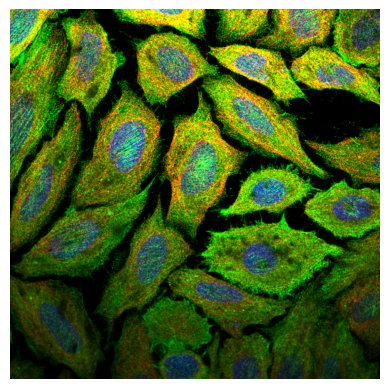

In [198]:
# Plot image
plot_image(np.array(image))

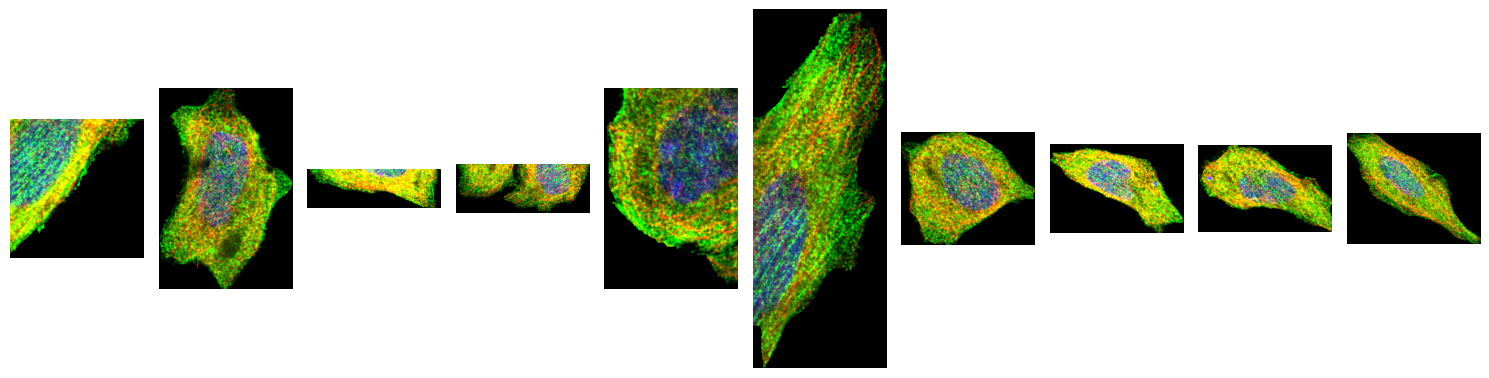

In [199]:
# Plot segmented cells
plot_segmented_cells(np.array(image), mask, margin=0)

### Predict Image and Segmented Cells

#### Single Cell Prediction
* Test different margins.
* Show the image and all the cells on a big plot (saved on de device).
* Run on all validation images and analyses the differences between image and cell predictions.

In [202]:
test_transform = valid_transformations(image_normalization='imagenet')

/home/juliana/.local/lib/python3.8/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [203]:
# Print
print("FILENAME: ", FILENAME)

# Get image
image = read_image_chw(FILENAME)

print("Image shape: ", image.shape)
print("Image dtype: ", image.dtype)

print("Mask shape: ", mask.shape)
print("Mask dtype: ", mask.dtype)

# Run model on cells
image_raw_logits, cell_raw_logits = run_model(
    image=image,
    mask=mask,
    margin=0.1,
    remove_background=False,
    use_bag=False,
    model=model,
    test_transform=test_transform,
    device=device
)

FILENAME:  9a3e9c84-bb9c-11e8-b2b9-ac1f6b6435d0
Image shape:  torch.Size([4, 2048, 2048])
Image dtype:  torch.uint8
Mask shape:  (2048, 2048)
Mask dtype:  uint16


In [204]:
# Get predictions for the image
prediction = get_multilabel_predictions(image_raw_logits, threshold=0.5)

# Get predictions for each cell
predictions = get_predictions_from_cell_raw_logits(cell_raw_logits, threshold=0.5)

print("Image prediction: ", prediction)

for cell_id, cell_prediction in predictions.items():
    print(f"Cell {cell_id[:10]} prediction: {cell_prediction}")

Image prediction:  ['Actin filaments', 'Plasma membrane']
Cell eNqNUk0Pgj prediction: ['Nucleoplasm', 'Cytosol']
Cell eNp1kmt3mz prediction: ['Nucleoplasm', 'Actin filaments', 'Cytosol']
Cell eNrNUtsKgk prediction: ['Cytosol']
Cell eNrFlVmPmz prediction: ['Nucleoplasm', 'Cytosol']
Cell eNqNUdsKwj prediction: ['Nucleoplasm', 'Cytosol']
Cell eNpVlNvSoz prediction: ['Nucleoplasm', 'Actin filaments', 'Cytosol']
Cell eNqNU9tygk prediction: ['Nucleoplasm', 'Actin filaments', 'Cytosol']
Cell eNqtVNuSoj prediction: ['Nucleoplasm', 'Cytosol']
Cell eNqtU01vwj prediction: ['Nucleoplasm', 'Cytosol']
Cell eNqVVG1Pwj prediction: ['Nucleoplasm', 'Actin filaments', 'Plasma membrane']
Cell eNqFU+lyoz prediction: ['Nucleoplasm', 'Actin filaments', 'Cytosol']
Cell eNqFU22Tmj prediction: ['Nucleoplasm', 'Actin filaments']
Cell eNp9U9ty4j prediction: ['Nucleoplasm', 'Actin filaments', 'Cytosol']
Cell eNqFU8EOwj prediction: ['Nucleoplasm', 'Cytosol']
Cell eNq1U80Ogj prediction: ['Nucleoplasm', 'Cytosol']
Ce

#### Bag of Cells Prediction

In [205]:
# Print
print("FILENAME: ", FILENAME)

# Get image
image = read_image_chw(FILENAME)

print("Image shape: ", image.shape)
print("Image dtype: ", image.dtype)

print("Mask shape: ", mask.shape)
print("Mask dtype: ", mask.dtype)

# Run model on cells
image_raw_logits, cell_raw_logits = run_model(
    image=image,
    mask=mask,
    margin=0,
    remove_background=False,
    use_bag=True,
    model=model,
    test_transform=test_transform,
    device=device
)

FILENAME:  9a3e9c84-bb9c-11e8-b2b9-ac1f6b6435d0
Image shape:  torch.Size([4, 2048, 2048])
Image dtype:  torch.uint8
Mask shape:  (2048, 2048)
Mask dtype:  uint16


In [206]:
# Get predictions for the image
prediction = get_multilabel_predictions(image_raw_logits, threshold=0.5)

# Get predictions for each cell
predictions = get_predictions_from_cell_raw_logits(cell_raw_logits, threshold=0.5)

print("Image prediction: ", prediction)

for cell_id, cell_prediction in predictions.items():
    print(f"Cell {cell_id[:10]} prediction: {cell_prediction}")

Image prediction:  ['Actin filaments', 'Plasma membrane']
Cell eNqNUk0Pgj prediction: ['Actin filaments']
Cell eNp1kmt3mz prediction: ['Nucleoplasm', 'Plasma membrane', 'Vesicles and punctate cytosolic patterns']
Cell eNrNUtsKgk prediction: []
Cell eNrFlVmPmz prediction: ['Nucleoplasm', 'Actin filaments']
Cell eNqNUdsKwj prediction: ['Cytosol']
Cell eNpVlNvSoz prediction: ['Actin filaments', 'Cytosol']
Cell eNqNU9tygk prediction: ['Nucleoplasm', 'Plasma membrane']
Cell eNqtVNuSoj prediction: ['Nucleoplasm']
Cell eNqtU01vwj prediction: []
Cell eNqVVG1Pwj prediction: ['Nucleoplasm', 'Plasma membrane']
Cell eNqFU+lyoz prediction: ['Nucleoli', 'Actin filaments', 'Plasma membrane']
Cell eNqFU22Tmj prediction: ['Nucleoplasm']
Cell eNp9U9ty4j prediction: ['Actin filaments', 'Mitochondria']
Cell eNqFU8EOwj prediction: ['Actin filaments', 'Centrosome']
Cell eNq1U80Ogj prediction: ['Nucleoplasm', 'Plasma membrane']
Cell eNp9U21Owz prediction: ['Nucleoplasm', 'Centrosome', 'Plasma membrane']
Cell

In [184]:
# Merge image and cell predictions
pred_str = merge_image_and_cell_raw_logits(
    image_raw_logits=image_raw_logits,
    cell_raw_logits=cell_raw_logits,
    image_weight=0.3,
    cell_weight=0.7,
    threshold=0.5
)

print("Prediction string:")
print(pred_str)

Prediction string:
0 0.7130 eNqtVFlzokAQ/kvTjIrJVvKw2Y1EsYmoHJqIqBwDiv//bad3nACrxqRqoYr++pjuZvp4fZ0doZ8fARxw+JiPFe0NiYJjoOIV/TpPX8aUTEsZ05Jao1+SfEd/i7/l93/JL+d547/3c1wPUwFx1/cwHgoBm+6E0FFA1gWyVw4Y02fHHA0dRGk/40nCbj4f1p6H7miTw6Gz8nE+inMoCfmEBKGQUNqJfNyOwhzeO6kn7XKWsFUOfkd4OBs9upDlUPCSmAcPkhwyvic7yaTSOZ9Jl3YpXXLXx6V9yCEhFJFsw6c+buwih2VXZtUbtq/YQF0AdSGq4eqy1/JmodQpRWsbetX1DHuKwjrAcjDNIO637OicA+04Ksb5owtdx1CD0LIJQ6yeVyks7s7ifJbvd3hd2roR23fELkRu2jb1bdq82X81l/03s7kkv37yfKSbffDZyJ3zP36rdXTeL7UldZNefnVcHb1ja81Xsr8+bGiMeXtU1XtNXuvReHeWb1j8Srewvg/+jq2yRsPuWH11XstWznSBk8Ehgaq/ZfUiaeaPxsANMRocU1j3vRCXgzKFXf8OjackwJn1lkFppgHOrTCDwswD9Kwgg8wsAwyteQY7szqh1Nx/oB3ZGXyRQUKnAwuMkHBGFoxwaiaEDZC4Ir8u+T2YIsCp5RN6ZOzFbPfMmD/fq//4+Ug0ciq5ZoaugLL76mP14gmY9OTqOSGpLV+mAopuduq+El0PA7sScul4hPYCUkKhXZJMbuKFXQhY8UhuYjsmFJ9yiDCc4VqOcr6HyIgb/ezA04PKi3YJUZ2nqkTgiAkO/ArMguogl7hcXHy0PyYx+wP5Atri 15 0.7804 eNqtVFlzokAQ/kvTjIrJVvKw2Y1EsYmoHJqIqBwDiv//bad3nACrxqRqoYr++pjuZvp4fZ0doZ8fARxw+JiPFe0NiYJjoOIV/TpPX8aUTEsZ05Jao1+Sf

In [185]:
# Supondo que pred_str seja algo como: "0 0.95 RLE_1 2 0.85 RLE_2 ..."
pred_list = pred_str.split()

# Mantemos apenas os pares (class_id, prob)
filtered_pred_str = " ".join(f"{pred_list[i]} {pred_list[i+1]}" for i in range(0, len(pred_list), 3))

print(filtered_pred_str)

0 0.7130 15 0.7804 0 0.7132 16 0.6907 8 0.8532 0 0.6393 7 0.7158 2 0.9685 7 0.6989 2 0.9949 16 0.6758 8 0.8717 8 0.6070 0 0.5101 15 0.7802 2 0.5597 8 0.8791 2 0.8436 15 0.7795 2 0.9950 2 0.9950 2 0.6564 8 0.6241


### Testing AREA

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define colors for each channel
channel_colors = {
    'blue': (0, 0, 1, 0.7),       # Blue with transparency
    'red': (1, 0, 0, 0.7),        # Red with transparency
    'yellow': (1, 0.6, 0, 0.7),   # Orange/Yellow with transparency
    'green': (0, 1, 0, 0.7)       # Green with transparency
}

def apply_channel_colors(image):
    """
    Applies color mapping to a 4-channel image.

    Args:
        image (np.ndarray): The 4-channel input image.

    Returns:
        np.ndarray: RGB image with blended channels.
    """
    # Initialize an empty RGB image
    combined_image = np.zeros(image.shape[:2] + (3,), dtype=np.float32)

    # Overlay each channel with corresponding color
    for j, (_, color) in enumerate(channel_colors.items()):
        channel = image[:, :, j].astype(np.float32)

        # Normalize channel to [0,1]
        channel = (channel - np.min(channel)) / (np.max(channel) - np.min(channel) + 1e-5)

        # Apply color mapping
        for k in range(3):
            combined_image[:, :, k] += channel * color[k]

    # Clip values to [0,1] for valid image display
    combined_image = np.clip(combined_image, 0, 1)

    return combined_image


def create_bag_of_cells(cell_image, target_size=(512, 512)):
    """
    Creates a bag of cells image by repeating the given cell multiple times to fill the target size.

    Args:
        cell_image (np.ndarray): The extracted cell image in (C, H, W) format.
        target_size (tuple): Desired output image size (H, W).

    Returns:
        np.ndarray: The new image containing multiple copies of the cell, still in (C, H, W) format.
    """
    C, cell_h, cell_w = cell_image.shape  # Extract channel, height, and width
    target_h, target_w = target_size

    # Estimate number of copies needed
    rows = max(1, target_h // cell_h)
    cols = max(1, target_w // cell_w)

    # Tile the image along height and width
    bag_of_cells = np.tile(cell_image, (1, rows, cols))[:, :target_h, :target_w]
    
    return bag_of_cells


def plot_bag_of_cells(image, mask, cell_id, target_size=(512, 512)):
    """
    Extracts a cell, applies color mapping, creates a bag of cells, and plots both images.

    Args:
        image (np.ndarray): The input image (4-channel format).
        mask (np.ndarray): The segmentation mask.
        cell_id (int): The ID of the cell to extract.
        target_size (tuple): Size of the bag of cells image.
    """
    # Extract the cell crop
    cell_image = extract_cell_crop(image, mask, cell_id)

    # Create the Bag of Cells image
    bag_of_cells = create_bag_of_cells(cell_image, target_size)

    # Apply color mapping to the cell image
    colored_cell = apply_channel_colors(cell_image)

    #Apply color mapping to the bag of cells image
    colored_bag = apply_channel_colors(bag_of_cells)

    # Plot the original cell and the bag of cells
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))

    ax[0].imshow(colored_cell)
    ax[0].set_title(f"Original Cell (ID: {cell_id})")
    ax[0].axis("off")

    ax[1].imshow(colored_bag)
    ax[1].set_title("Bag of Cells")
    ax[1].axis("off")

    plt.show()

FILENAME:  9a3e9c84-bb9c-11e8-b2b9-ac1f6b6435d0


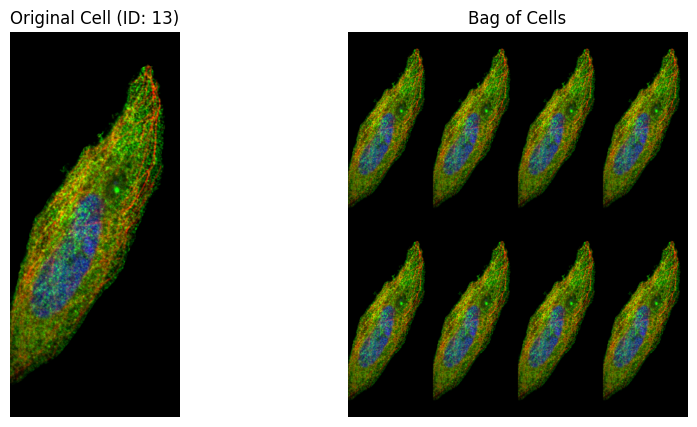

In [ ]:
transforms = valid_transformations(image_normalization='imagenet')

# Get image
print("FILENAME: ", FILENAME)

# Pegar todas a imagens
colors = ["_blue", "_red", "_yellow", "_green"]
images = [read_image(os.path.join(ROOT + "train/" + FILENAME + color + ".png")) for color in colors]
image = torch.cat(images, 0)

# Colocar os canais por último -> formato HWC
image = image.permute(1, 2, 0)
image = np.array(image)

# Example usage:
# Select a random cell from the mask
cell_ids = np.unique(mask)
cell_ids = cell_ids[cell_ids != 0]  # Remove background
random_cell_id = np.random.choice(cell_ids)

# Plot the bag of cells example
plot_bag_of_cells(image, mask, random_cell_id, target_size=(image.shape[0], image.shape[1]))

In [ ]:
# Predict image 
image = train[0][0]
label = train[0][1]

print("Image shape: ", image.shape)
print("Label shape: ", label.shape)

logits = model(image.unsqueeze(0))
predictions = get_multilabel_predictions(logits)

print("FILENAME: ", train.filenames[0])
print("Label: ", label)
print("Predictions: ", predictions)


Image shape:  torch.Size([4, 512, 512])
Label shape:  torch.Size([19])
FILENAME:  9a3e9c84-bb9c-11e8-b2b9-ac1f6b6435d0
Label:  tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1., 0., 0., 0., 0.,
        0.])
Predictions:  ['Actin filaments', 'Plasma membrane']
